## **3점 굽힘(3-Point Bending) 시험 분석**

기계시스템공학실험(B) 고체생산 2주차

---
`tens_result`: 알루미늄 Transverse 시편 (횡방향 결정립 방향성)

`long_result`: 알루미늄 Longitudinal 시편 (종방향 결정립 방향성)
<br><br>

실험 분석을 위해 사용한 라이브러리 및 용도는 다음과 같습니다.


`pandas`: csv 형태의 데이터를 처리하기 위해 사용하였다.

`matplotlib`: Python의 시각화 라이브러리로, 각종 선도(Curve)의 시각화를 위해 사용하였다.

`numpy`: 다차원 array 처리용 Python 라이브러리로, 물성치 계산을 위해 사용하였다.

<br><br>
이외 자세한 실험 과정 및 결과는 실험 보고서를 참고 바랍니다.

In [68]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

tens_result = pd.read_csv("D:/00 기계공학실험/고체 생산/Bending_Al_Transverse_B04_02.csv", encoding='euc-kr')
long_result = pd.read_csv("D:/00 기계공학실험/고체 생산/Bending_Al_Longitudinal_B04_02.csv", encoding='euc-kr')

display(tens_result.head())
display(long_result.head())

,일련번호,시간,하중,변위,강도,변형율
0,NaN,[sec],[kgf],[mm],[kgf/mm²],[%]
1,1.0,0.000,0.000000,0.000000,0.000000,0.000000
2,2.0,0.000,1.900000,0.000000,0.157785,0.000000
3,3.0,0.011,2.500000,0.090000,0.207612,0.011475
4,4.0,0.018,3.100000,0.100000,0.257439,0.012750


,일련번호,시간,하중,변위,강도,변형율
0,NaN,[sec],[kgf],[mm],[kgf/mm²],[%]
1,1.0,0.000,0.000000,0.000000,0.000000,0.000000
2,2.0,0.000,6.700000,0.000000,0.361661,0.000000
3,3.0,0.009,7.600000,0.090000,0.410242,0.027160
4,4.0,0.016,8.500000,0.100000,0.458824,0.030178


## **Transverse 시편 분석**

Transverse 시편에 대해 '하중-처짐 선도'와 '공칭 응력-변형률 선도'를 도식한다.

이후 선형탄성 구간에 대해 '하중-처짐 선도'의 기울기 m을 산출한다.

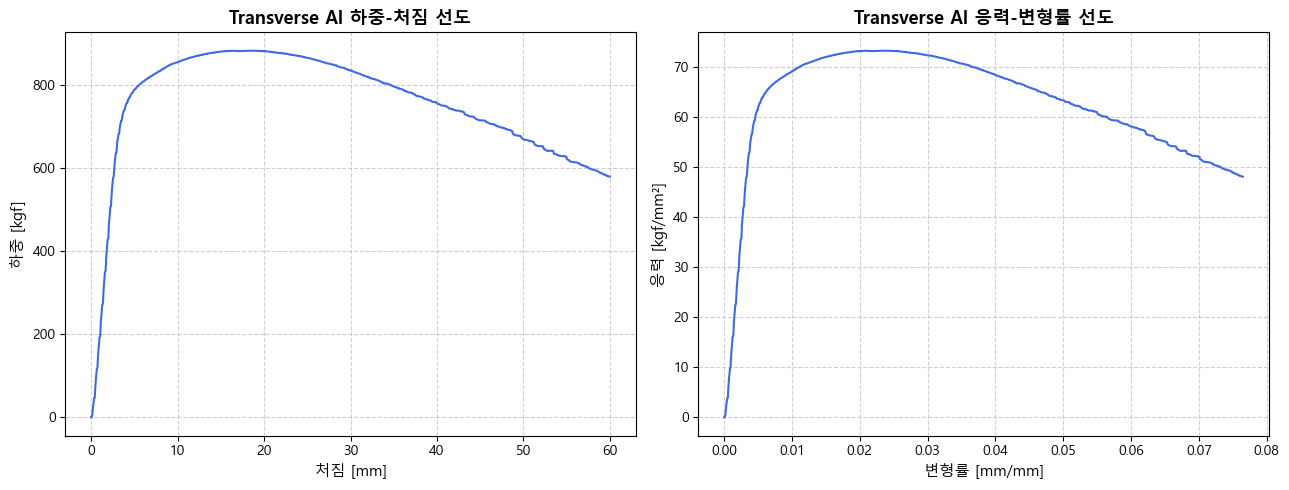

In [69]:
# 데이터 전처리
tens_result['변형률'] = None
tens_result.loc[0, '변형률'] = '[mm/mm]'
tens_result.loc[1:, '변형률'] = pd.to_numeric(tens_result.loc[1:, '변형율']) / 100

tens_result = tens_result.rename(columns={'변위': '처짐', '강도': '응력'})

## 그래프
plot_data = tens_result.iloc[1:].copy()
for col in ['처짐', '하중', '변형률', '응력']:
    plot_data[col] = pd.to_numeric(plot_data[col])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 하중-처짐 선도
axes[0].plot(plot_data['처짐'], plot_data['하중'], color='royalblue', linewidth=1.5)
axes[0].set_title('Transverse Al 하중-처짐 선도', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f"처짐 {tens_result.loc[0, '처짐']}", fontsize=11)
axes[0].set_ylabel(f"하중 {tens_result.loc[0, '하중']}", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)

# 응력-변형률 선도
axes[1].plot(plot_data['변형률'], plot_data['응력'], color='royalblue', linewidth=1.5)
axes[1].set_title('Transverse Al 응력-변형률 선도', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f"변형률 {tens_result.loc[0, '변형률']}", fontsize=11)
axes[1].set_ylabel(f"응력 {tens_result.loc[0, '응력']}", fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

#### **선형 탄성 구간 기울기 m을 구하는 과정에서**

Transverse Al 시편의 경우 두 방법을 통해 하중-처짐 선도의 선형탄성 구간에 해당하는 기울기 m을 구했다. 

1. 선형 탄성구간의 3개의 점의 기울기 평균값으로 m값을 구하는 경우

2. 1차 선형 다항식 Fitting을 통해 m값을 구하는 경우

점 a: 처짐 = 1.05 mm, 하중 = 198.9 kgf
점 b: 처짐 = 1.79 mm, 하중 = 401.0 kgf
점 c: 처짐 = 2.66 mm, 하중 = 599.7 kgf
m_ab = 273.11, m_bc = 228.39, m_ca = 248.94
평균 기울기 m: 250.15 kgf/mm


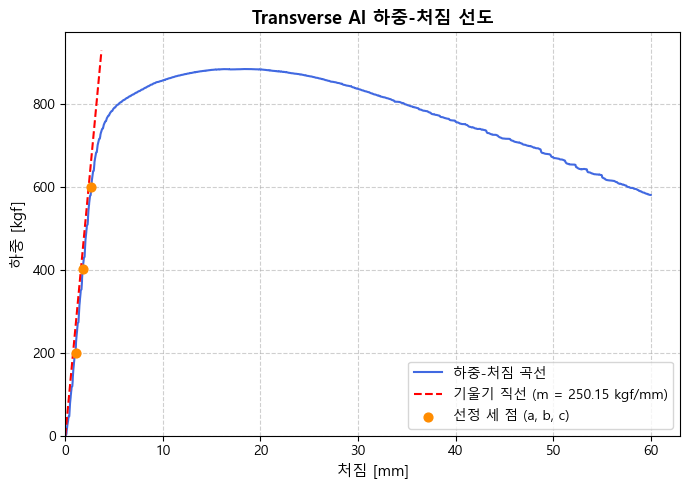

In [70]:
## 탄성 구간 3점 기울기를 통해 m값을 계산하는 경우 
pre_peak = plot_data.loc[:plot_data['하중'].idxmax()]

idx_a = (pre_peak['하중'] - 200).abs().idxmin()
idx_b = (pre_peak['하중'] - 400).abs().idxmin()
idx_c = (pre_peak['하중'] - 600).abs().idxmin()

pt_a = pre_peak.loc[idx_a]
pt_b = pre_peak.loc[idx_b]
pt_c = pre_peak.loc[idx_c]
m_ab = (pt_b['하중'] - pt_a['하중']) / (pt_b['처짐'] - pt_a['처짐'])
m_bc = (pt_c['하중'] - pt_b['하중']) / (pt_c['처짐'] - pt_b['처짐'])
m_ca = (pt_c['하중'] - pt_a['하중']) / (pt_c['처짐'] - pt_a['처짐'])

m_3pts = (m_ab + m_bc + m_ca) / 3

print(f"점 a: 처짐 = {pt_a['처짐']:.2f} mm, 하중 = {pt_a['하중']:.1f} kgf")
print(f"점 b: 처짐 = {pt_b['처짐']:.2f} mm, 하중 = {pt_b['하중']:.1f} kgf")
print(f"점 c: 처짐 = {pt_c['처짐']:.2f} mm, 하중 = {pt_c['하중']:.1f} kgf")
print(f"m_ab = {m_ab:.2f}, m_bc = {m_bc:.2f}, m_ca = {m_ca:.2f}")
print(f"평균 기울기 m: {m_3pts:.2f} kgf/mm")

## 그래프
max_load = plot_data['하중'].max()
x_line = np.linspace(0, (max_load * 1.05) / m_3pts, 100)

plt.figure(figsize=(7, 5))
plt.plot(plot_data['처짐'], plot_data['하중'], color='royalblue', linewidth=1.5, label='하중-처짐 곡선')
plt.plot(x_line, m_3pts * x_line, '--', color='red', linewidth=1.5, 
         label=f'기울기 직선 (m = {m_3pts:.2f} kgf/mm)')
plt.scatter([pt_a['처짐'], pt_b['처짐'], pt_c['처짐']], 
            [pt_a['하중'], pt_b['하중'], pt_c['하중']], 
            color='darkorange', s=40, zorder=5, label='선정 세 점 (a, b, c)')

plt.title('Transverse Al 하중-처짐 선도', fontsize=13, fontweight='bold')
plt.xlabel(f"처짐 {tens_result.loc[0, '처짐']}", fontsize=11)
plt.ylabel(f"하중 {tens_result.loc[0, '하중']}", fontsize=11)

# x축, y축 0에서 시작
plt.xlim(left=0)
plt.ylim(bottom=0, top=max_load * 1.1)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

피팅 기울기 m: 254.06 kgf/mm (R² = 0.9965)


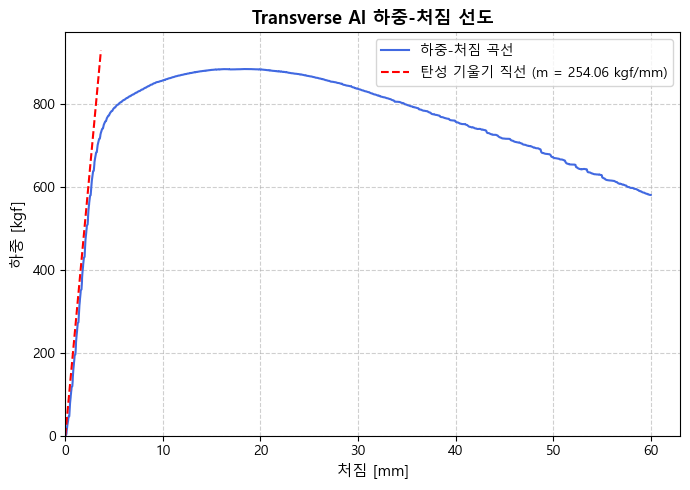

In [71]:
## 곡선에 대한 1차 선형 다항식 Fitting
pre_peak = plot_data.loc[:plot_data['하중'].idxmax()]
elastic_region = pre_peak[(pre_peak['처짐'] >= 1.0) & (pre_peak['처짐'] <= 2.2)]

# 1차 선형 다항식 Fitting
m_fit, c_fit = np.polyfit(elastic_region['처짐'], elastic_region['하중'], deg=1)
# 결정계수(R^2)
residuals = elastic_region['하중'] - (m_fit * elastic_region['처짐'] + c_fit)
r_squared = 1 - (np.sum(residuals**2) / np.sum((elastic_region['하중'] - elastic_region['하중'].mean())**2))

print(f"피팅 기울기 m: {m_fit:.2f} kgf/mm (R² = {r_squared:.4f})")

## 그래프
max_load = plot_data['하중'].max()
x_line = np.linspace(0, (max_load * 1.05) / m_fit, 100)

plt.figure(figsize=(7, 5))
plt.plot(plot_data['처짐'], plot_data['하중'], color='royalblue', linewidth=1.5, label='하중-처짐 곡선')
plt.plot(x_line, m_fit * x_line, '--', color='red', linewidth=1.5, 
         label=f'탄성 기울기 직선 (m = {m_fit:.2f} kgf/mm)')

plt.title('Transverse Al 하중-처짐 선도', fontsize=13, fontweight='bold')
plt.xlabel(f"처짐 {tens_result.loc[0, '처짐']}", fontsize=11)
plt.ylabel(f"하중 {tens_result.loc[0, '하중']}", fontsize=11)

plt.xlim(left=0)
plt.ylim(bottom=0, top=max_load * 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

[선형 피팅 기울기 m_fit]
  - kgf 단위: 254.06 kgf/mm
  - N 단위  : 2491.45 N/mm (2.491 kN/mm)

[3개 점 평균 기울기 m_3pts]
  - kgf 단위: 250.15 kgf/mm
  - N 단위  : 2453.11 N/mm (2.453 kN/mm)


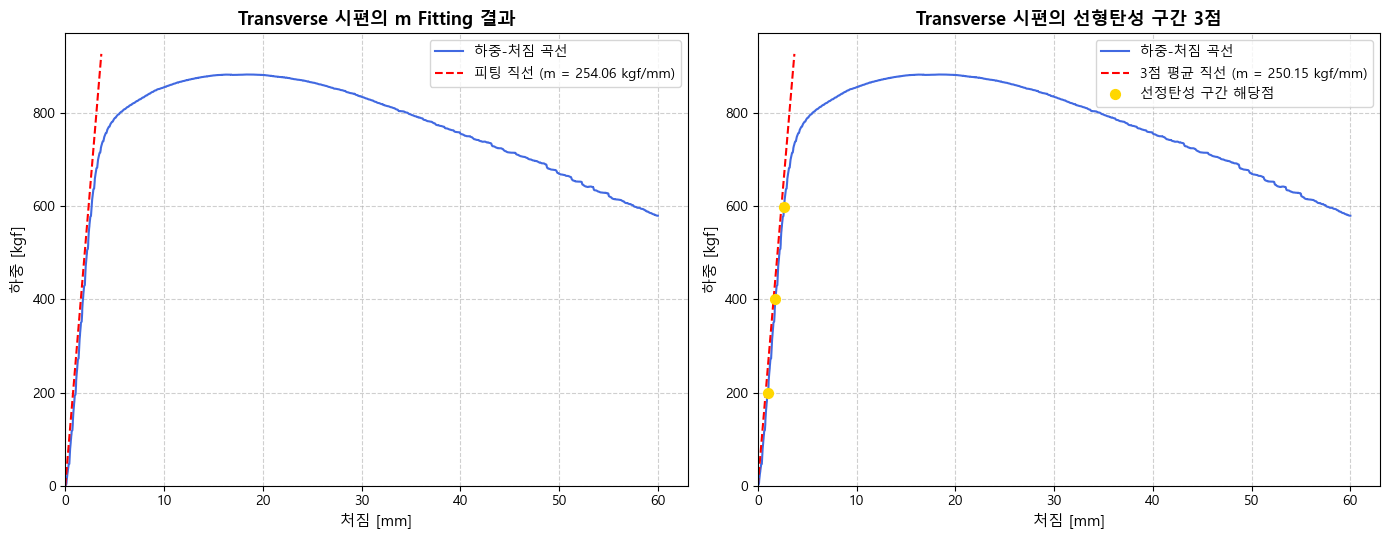

In [72]:
# 단위 변환
g = 9.80665
m_fit_kgf = m_fit
m_fit_N = m_fit_kgf * g
m_fit_kN = m_fit_N / 1000

m_3pts_kgf = m_3pts
m_3pts_N = m_3pts_kgf * g
m_3pts_kN = m_3pts_N / 1000

print(f"[선형 피팅 기울기 m_fit]")
print(f"  - kgf 단위: {m_fit_kgf:.2f} kgf/mm")
print(f"  - N 단위  : {m_fit_N:.2f} N/mm ({m_fit_kN:.3f} kN/mm)\n")

print(f"[3개 점 평균 기울기 m_3pts]")
print(f"  - kgf 단위: {m_3pts_kgf:.2f} kgf/mm")
print(f"  - N 단위  : {m_3pts_N:.2f} N/mm ({m_3pts_kN:.3f} kN/mm)")

## 그래프
max_load = plot_data['하중'].max()
load_unit = tens_result.loc[0, '하중']
defl_unit = tens_result.loc[0, '처짐']
x_line_fit = np.linspace(0, (max_load * 1.05) / m_fit, 100)
x_line_3pts = np.linspace(0, (max_load * 1.05) / m_3pts, 100)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# 선형 피팅 (m_fit) 하중-처짐 선도
axes[0].plot(plot_data['처짐'], plot_data['하중'], color='royalblue', linewidth=1.5, label='하중-처짐 곡선')
axes[0].plot(x_line_fit, m_fit * x_line_fit, '--', color='red', linewidth=1.5, 
             label=f'피팅 직선 (m = {m_fit:.2f} kgf/mm)')
axes[0].set_title('Transverse 시편의 m Fitting 결과', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f"처짐 {defl_unit}", fontsize=11)
axes[0].set_ylabel(f"하중 {load_unit}", fontsize=11)
axes[0].set_xlim(left=0)
axes[0].set_ylim(bottom=0, top=max_load * 1.1)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(loc='best', fontsize=10)

# 3개 점 평균 (m_3pts) 하중-처짐 선도
axes[1].plot(plot_data['처짐'], plot_data['하중'], color='royalblue', linewidth=1.5, label='하중-처짐 곡선')
axes[1].plot(x_line_3pts, m_3pts * x_line_3pts, '--', color='red', linewidth=1.5, 
             label=f'3점 평균 직선 (m = {m_3pts:.2f} kgf/mm)')

axes[1].scatter([pt_a['처짐'], pt_b['처짐'], pt_c['처짐']], 
                [pt_a['하중'], pt_b['하중'], pt_c['하중']], 
                color='gold', s=50, zorder=5, label='선정탄성 구간 해당점')
axes[1].set_title('Transverse 시편의 선형탄성 구간 3점', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f"처짐 {defl_unit}", fontsize=11)
axes[1].set_ylabel(f"하중 {load_unit}", fontsize=11)
axes[1].set_xlim(left=0)
axes[1].set_ylim(bottom=0, top=max_load * 1.1)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(loc='best', fontsize=10)

plt.tight_layout()
plt.show()

### **선형 탄성 구간에서의 Beam Theory**

Transverse 시편의 선형 탄성 구간에서 Beam Theory를 따른 거동을 보이는지를 '처짐','응력','변형률'의 관점에서 살펴본다.

처짐(Deflection), 굽힘 응력(Flexural stress), 굽힘 변형률(Flexural Strain)에 대한 Beam Theory 이론식은 보고서 참고.

이론값 및 실험값을 그래프에 표시하고 그에 따른 결정계수 값을 출력한다.

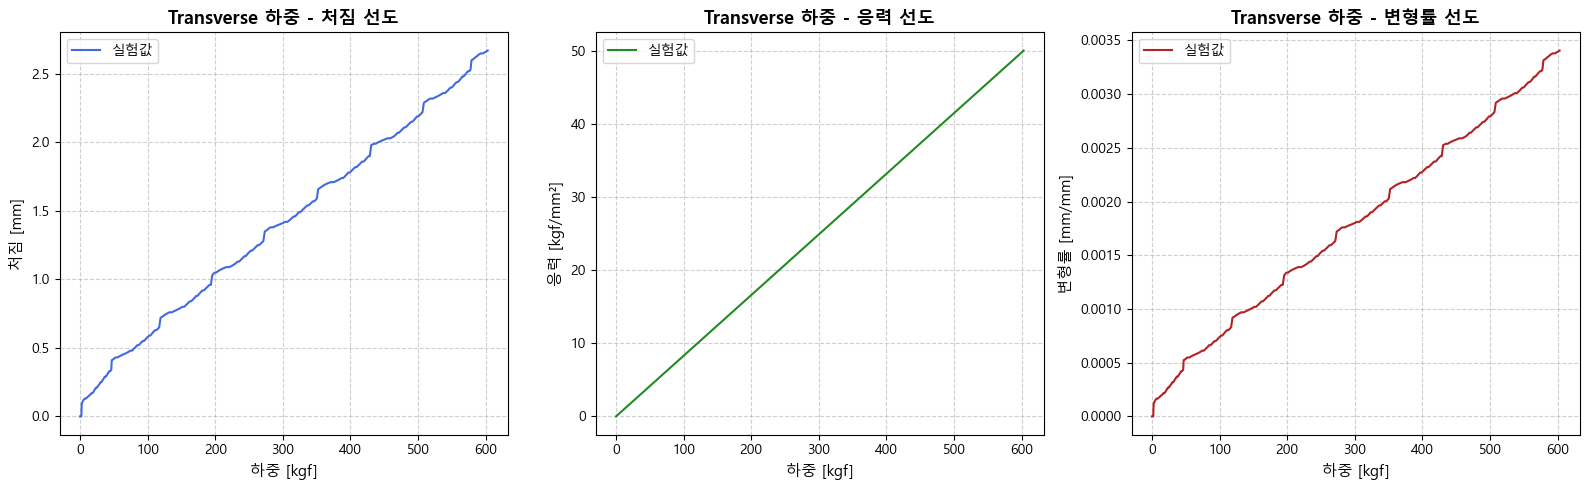

In [73]:
tens_result.loc[1:, '하중'] = pd.to_numeric(tens_result.loc[1:, '하중'])
tens_result.loc[1:, '처짐'] = pd.to_numeric(tens_result.loc[1:, '처짐'])
tens_result.loc[1:, '응력'] = pd.to_numeric(tens_result.loc[1:, '응력'])
tens_result.loc[1:, '변형률'] = pd.to_numeric(tens_result.loc[1:, '변형률'])

## 선형탄성 구간만
first_600_idx = tens_result.loc[1:][tens_result.loc[1:, '하중'] >= 600].index[0]
plot_data = tens_result.loc[1:first_600_idx].copy()
tens_elastic = pd.concat([tens_result.iloc[[0]], plot_data])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (1) 하중 - 처짐 (변위)
axes[0].plot(plot_data['하중'],plot_data['처짐'],color='royalblue',linewidth=1.5,label='실험값',)
axes[0].set_title('Transverse 하중 - 처짐 선도', fontsize=13, fontweight='bold')
axes[0].set_xlabel('하중 [kgf]', fontsize=11)
axes[0].set_ylabel('처짐 [mm]', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# (2) 하중 - 응력 (강도)
axes[1].plot(plot_data['하중'],plot_data['응력'],color='forestgreen',linewidth=1.5,label='실험값',)
axes[1].set_title('Transverse 하중 - 응력 선도', fontsize=13, fontweight='bold')
axes[1].set_xlabel('하중 [kgf]', fontsize=11)
axes[1].set_ylabel('응력 [kgf/mm²]', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

# (3) 하중 - 변형률
axes[2].plot(plot_data['하중'],plot_data['변형률'],color='firebrick',linewidth=1.5,label='실험값',)
axes[2].set_title('Transverse 하중 - 변형률 선도', fontsize=13, fontweight='bold')
axes[2].set_xlabel('하중 [kgf]', fontsize=11)
axes[2].set_ylabel('변형률 [mm/mm]', fontsize=11)
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend()

plt.tight_layout()
plt.show()

In [83]:
## Beam Theory
L = 130.0  # 지간거리 [mm]
b = 50.0  # 시편 너비 [mm]
d = 8.5  # 시편 두께 [mm]

coeff_delta = (L**3) / (4 * b * (d**3))
coeff_sigma = (3 * L) / (2 * b * (d**2))
coeff_eps = (3 * L) / (2 * b * (d**2))

gpa_to_kgf_mm2 = 1000.0 / 9.80665
coeff_delta_gpa = coeff_delta / gpa_to_kgf_mm2
coeff_eps_gpa = coeff_eps / gpa_to_kgf_mm2

print("=" * 65)
print(f"변위 [mm]      | ({coeff_delta_gpa:.6f} / E_f[GPa]) * P")
print(f"강도 [kgf/mm²] | {coeff_sigma:.6f} * P")
print(f"변형률 [mm/mm] | ({coeff_eps_gpa:.7f} / E_f[GPa]) * P")
print("=" * 65)

변위 [mm]      | (0.175414 / E_f[GPa]) * P
강도 [kgf/mm²] | 0.053979 * P
변형률 [mm/mm] | (0.0005294 / E_f[GPa]) * P


             선형탄성 구간 R-squared (R²) 계산 결과
하중-처짐 선도   | R² = 0.9223
하중-응력 선도   | R² = 1.0000
하중-변형률 선도 | R² = 0.9225


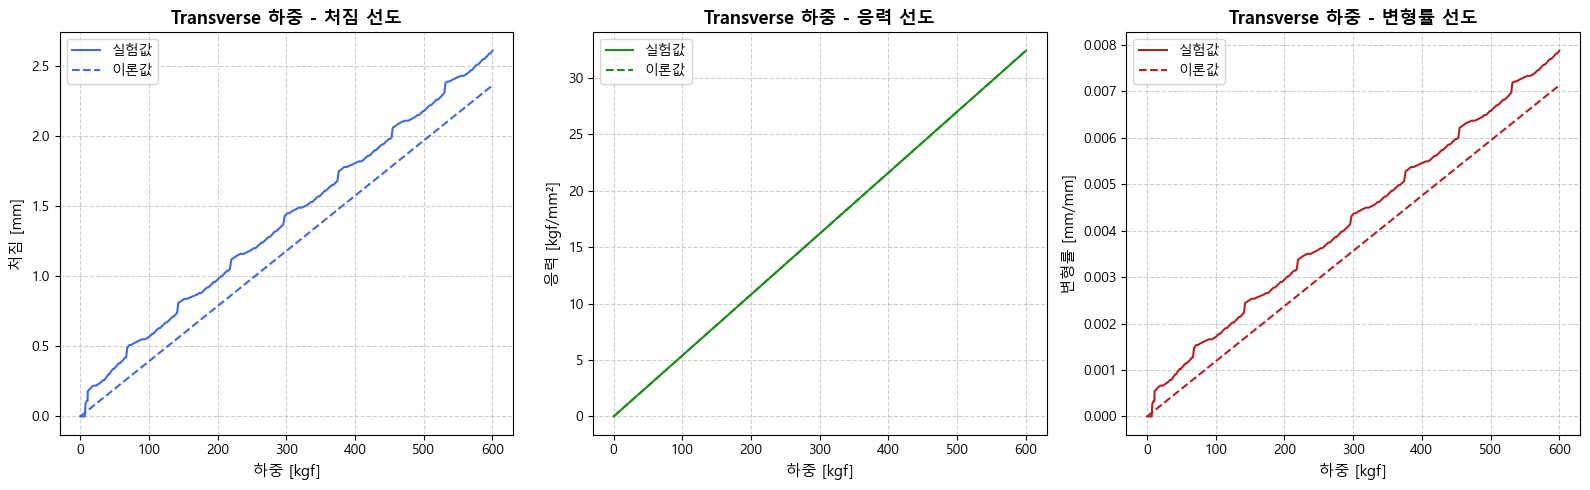

In [86]:
plot_data[['하중', '처짐', '응력', '변형률']] = plot_data[['하중', '처짐', '응력', '변형률']].astype(float)

E_f = 44.56 # GPa

coeff_delta_gpa = 0.1754
coeff_sigma = 0.05398  
coeff_eps_gpa = 0.0005294

P = plot_data['하중']
theory_deflection = (coeff_delta_gpa / E_f) * P
theory_stress = coeff_sigma * P
theory_strain = (coeff_eps_gpa / E_f) * P

# 결정계수 계산 함수 
def calc_r2_theory(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

# 각 선도별 R² 산출
r2_def_fit = calc_r2_theory(plot_data['처짐'], theory_deflection)
r2_stress_fit = calc_r2_theory(plot_data['응력'], theory_stress)
r2_strain_fit = calc_r2_theory(plot_data['변형률'], theory_strain)

# R² 콘솔 출력
print("=" * 60)
print("             선형탄성 구간 R-squared (R²) 계산 결과")
print("=" * 60)
print(f"하중-처짐 선도   | R² = {r2_def_fit:.4f}")
print(f"하중-응력 선도   | R² = {r2_stress_fit:.4f}")
print(f"하중-변형률 선도 | R² = {r2_strain_fit:.4f}")
print("=" * 60)

## 그래프
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 하중-처짐 선도
axes[0].plot(plot_data['하중'], plot_data['처짐'], color='royalblue', linewidth=1.5, label='실험값')
axes[0].plot(plot_data['하중'], theory_deflection, color='royalblue', linestyle='--', linewidth=1.5, label='이론값')
axes[0].set_title('Transverse 하중 - 처짐 선도', fontsize=13, fontweight='bold')
axes[0].set_xlabel('하중 [kgf]', fontsize=11)
axes[0].set_ylabel('처짐 [mm]', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# 하중-응력 선도
axes[1].plot(plot_data['하중'], plot_data['응력'], color='forestgreen', linewidth=1.5, label='실험값')
axes[1].plot(plot_data['하중'], theory_stress, color='forestgreen', linestyle='--', linewidth=1.5, label='이론값')
axes[1].set_title('Transverse 하중 - 응력 선도', fontsize=13, fontweight='bold')
axes[1].set_xlabel('하중 [kgf]', fontsize=11)
axes[1].set_ylabel('응력 [kgf/mm²]', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

# 하중-변형률 선도
axes[2].plot(plot_data['하중'], plot_data['변형률'], color='firebrick', linewidth=1.5, label='실험값')
axes[2].plot(plot_data['하중'], theory_strain, color='firebrick', linestyle='--', linewidth=1.5, label='이론값')
axes[2].set_title('Transverse 하중 - 변형률 선도', fontsize=13, fontweight='bold')
axes[2].set_xlabel('하중 [kgf]', fontsize=11)
axes[2].set_ylabel('변형률 [mm/mm]', fontsize=11)
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend()

plt.tight_layout()
plt.show()

## **Longitudinal 시편 분석**

Longitudinal 시편에 대해 '하중-처짐 선도'와 '공칭 응력-변형률 선도'를 도식한다. (Transverse 시편고 동일한 분석을 수행한다.)

이후 선형탄성 구간에 대해 '하중-처짐 선도'의 기울기 m을 산출한다.

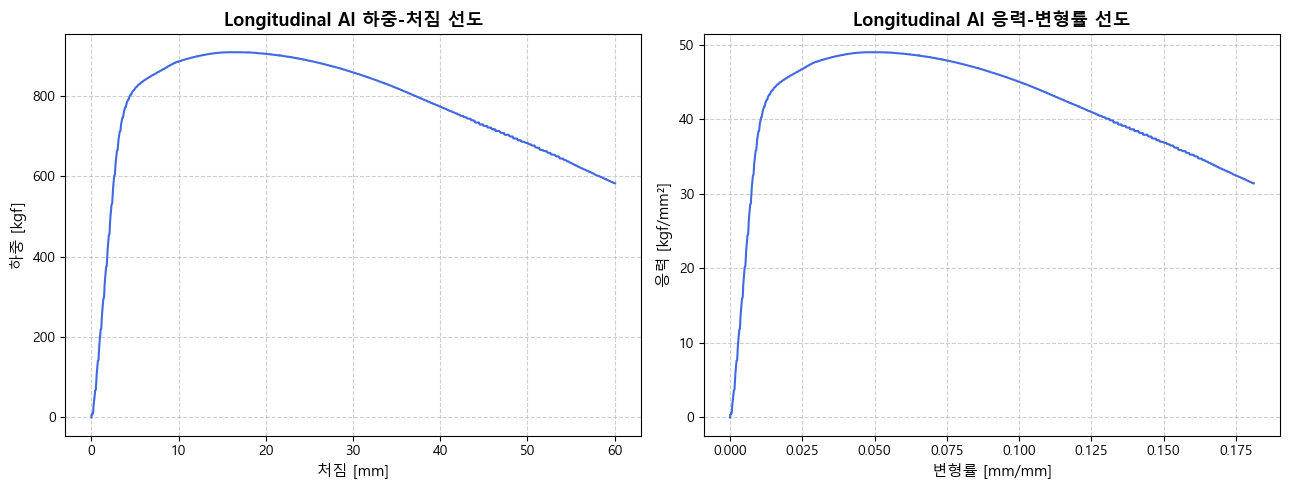

In [76]:
# 데이터 전처리
long_result['변형률'] = None
long_result.loc[0, '변형률'] = '[mm/mm]'
long_result.loc[1:, '변형률'] = pd.to_numeric(long_result.loc[1:, '변형율']) / 100

long_result = long_result.rename(columns={'변위': '처짐', '강도': '응력'})

## 그래프
plot_data = long_result.iloc[1:].copy()
for col in ['처짐', '하중', '변형률', '응력']:
    plot_data[col] = pd.to_numeric(plot_data[col])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 하중-처짐 선도
axes[0].plot(plot_data['처짐'], plot_data['하중'], color='royalblue', linewidth=1.5)
axes[0].set_title('Longitudinal Al 하중-처짐 선도', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f"처짐 {long_result.loc[0, '처짐']}", fontsize=11)
axes[0].set_ylabel(f"하중 {long_result.loc[0, '하중']}", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)

# 응력-변형률 선도
axes[1].plot(plot_data['변형률'], plot_data['응력'], color='royalblue', linewidth=1.5)
axes[1].set_title('Longitudinal Al 응력-변형률 선도', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f"변형률 {long_result.loc[0, '변형률']}", fontsize=11)
axes[1].set_ylabel(f"응력 {long_result.loc[0, '응력']}", fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

점 a: 처짐 = 0.98 mm, 하중 = 200.6 kgf
점 b: 처짐 = 1.81 mm, 하중 = 401.9 kgf
점 c: 처짐 = 2.61 mm, 하중 = 600.2 kgf
m_ab = 242.53, m_bc = 247.88, m_ca = 245.15
평균 기울기 m: 245.19 kgf/mm


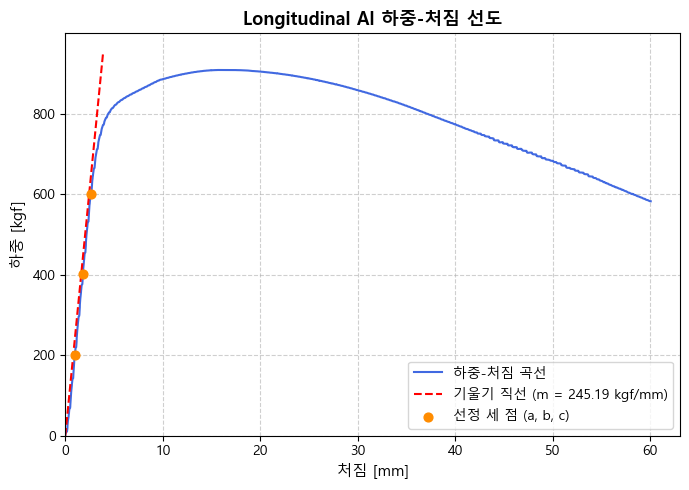

In [77]:
## 탄성 구간 3점 기울기를 통해 m값을 계산하는 경우 
pre_peak = plot_data.loc[:plot_data['하중'].idxmax()]

idx_a = (pre_peak['하중'] - 200).abs().idxmin()
idx_b = (pre_peak['하중'] - 400).abs().idxmin()
idx_c = (pre_peak['하중'] - 600).abs().idxmin()

pt_a = pre_peak.loc[idx_a]
pt_b = pre_peak.loc[idx_b]
pt_c = pre_peak.loc[idx_c]
m_ab = (pt_b['하중'] - pt_a['하중']) / (pt_b['처짐'] - pt_a['처짐'])
m_bc = (pt_c['하중'] - pt_b['하중']) / (pt_c['처짐'] - pt_b['처짐'])
m_ca = (pt_c['하중'] - pt_a['하중']) / (pt_c['처짐'] - pt_a['처짐'])

m_3pts = (m_ab + m_bc + m_ca) / 3

print(f"점 a: 처짐 = {pt_a['처짐']:.2f} mm, 하중 = {pt_a['하중']:.1f} kgf")
print(f"점 b: 처짐 = {pt_b['처짐']:.2f} mm, 하중 = {pt_b['하중']:.1f} kgf")
print(f"점 c: 처짐 = {pt_c['처짐']:.2f} mm, 하중 = {pt_c['하중']:.1f} kgf")
print(f"m_ab = {m_ab:.2f}, m_bc = {m_bc:.2f}, m_ca = {m_ca:.2f}")
print(f"평균 기울기 m: {m_3pts:.2f} kgf/mm")

## 그래프
max_load = plot_data['하중'].max()
x_line = np.linspace(0, (max_load * 1.05) / m_3pts, 100)

plt.figure(figsize=(7, 5))
plt.plot(plot_data['처짐'], plot_data['하중'], color='royalblue', linewidth=1.5, label='하중-처짐 곡선')
plt.plot(x_line, m_3pts * x_line, '--', color='red', linewidth=1.5, 
         label=f'기울기 직선 (m = {m_3pts:.2f} kgf/mm)')
plt.scatter([pt_a['처짐'], pt_b['처짐'], pt_c['처짐']], 
            [pt_a['하중'], pt_b['하중'], pt_c['하중']], 
            color='darkorange', s=40, zorder=5, label='선정 세 점 (a, b, c)')

plt.title('Longitudinal Al 하중-처짐 선도', fontsize=13, fontweight='bold')
plt.xlabel(f"처짐 {long_result.loc[0, '처짐']}", fontsize=11)
plt.ylabel(f"하중 {long_result.loc[0, '하중']}", fontsize=11)

# x축, y축 0에서 시작
plt.xlim(left=0)
plt.ylim(bottom=0, top=max_load * 1.1)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

피팅 기울기 m: 249.73 kgf/mm (R² = 0.9963)


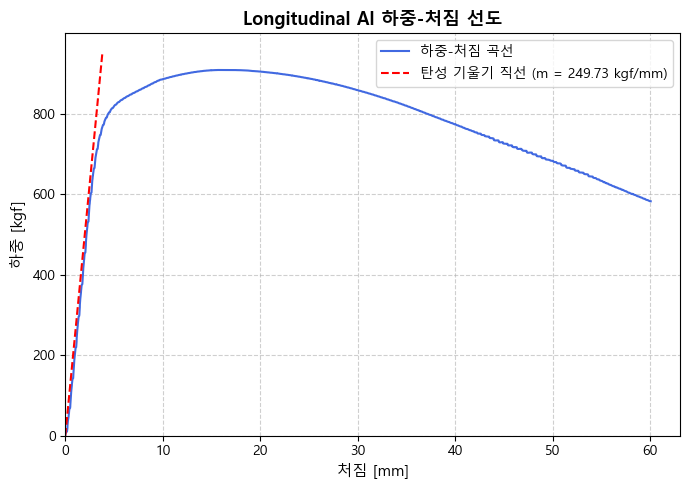

In [78]:
## 곡선에 대한 1차 선형 다항식 Fitting
pre_peak = plot_data.loc[:plot_data['하중'].idxmax()]
elastic_region = pre_peak[(pre_peak['처짐'] >= 1.0) & (pre_peak['처짐'] <= 2.2)]

# 1차 선형 다항식 Fitting
m_fit, c_fit = np.polyfit(elastic_region['처짐'], elastic_region['하중'], deg=1)
# 결정계수(R^2)
residuals = elastic_region['하중'] - (m_fit * elastic_region['처짐'] + c_fit)
r_squared = 1 - (np.sum(residuals**2) / np.sum((elastic_region['하중'] - elastic_region['하중'].mean())**2))

print(f"피팅 기울기 m: {m_fit:.2f} kgf/mm (R² = {r_squared:.4f})")

## 그래프
max_load = plot_data['하중'].max()
x_line = np.linspace(0, (max_load * 1.05) / m_fit, 100)

plt.figure(figsize=(7, 5))
plt.plot(plot_data['처짐'], plot_data['하중'], color='royalblue', linewidth=1.5, label='하중-처짐 곡선')
plt.plot(x_line, m_fit * x_line, '--', color='red', linewidth=1.5, 
         label=f'탄성 기울기 직선 (m = {m_fit:.2f} kgf/mm)')

plt.title('Longitudinal Al 하중-처짐 선도', fontsize=13, fontweight='bold')
plt.xlabel(f"처짐 {long_result.loc[0, '처짐']}", fontsize=11)
plt.ylabel(f"하중 {long_result.loc[0, '하중']}", fontsize=11)

plt.xlim(left=0)
plt.ylim(bottom=0, top=max_load * 1.1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='best', fontsize=10)
plt.tight_layout()
plt.show()

[선형 피팅 기울기 m_fit]
  - kgf 단위: 249.73 kgf/mm
  - N 단위  : 2448.99 N/mm (2.449 kN/mm)

[3개 점 평균 기울기 m_3pts]
  - kgf 단위: 245.19 kgf/mm
  - N 단위  : 2404.45 N/mm (2.404 kN/mm)


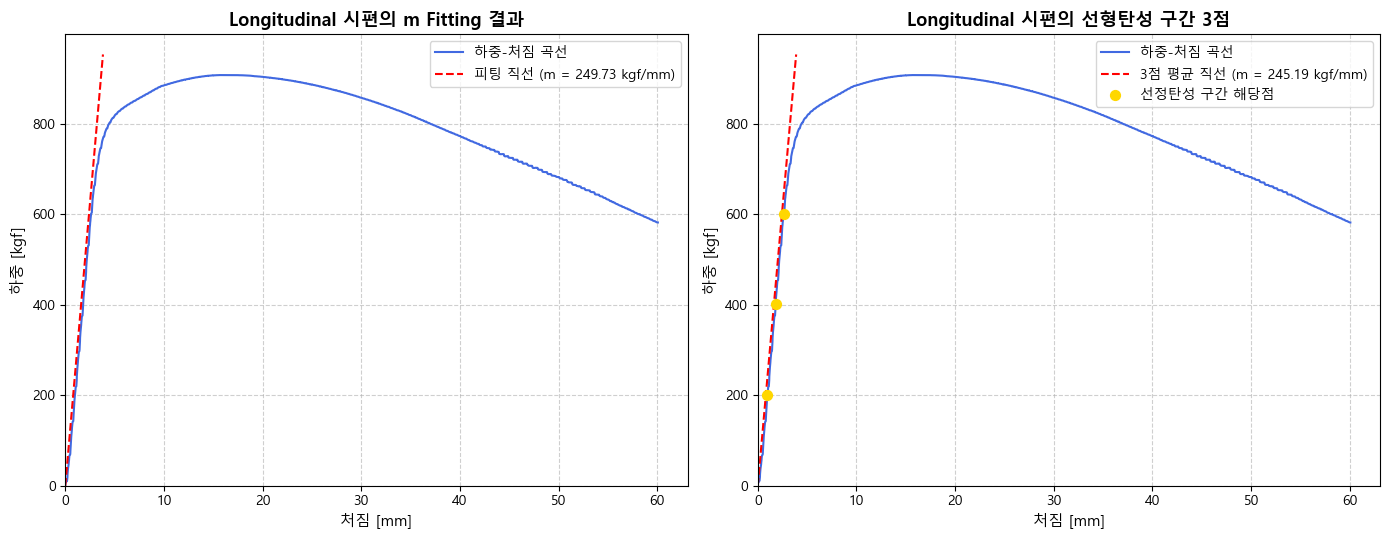

In [79]:
# 단위 변환
g = 9.80665
m_fit_kgf = m_fit
m_fit_N = m_fit_kgf * g
m_fit_kN = m_fit_N / 1000

m_3pts_kgf = m_3pts
m_3pts_N = m_3pts_kgf * g
m_3pts_kN = m_3pts_N / 1000

print(f"[선형 피팅 기울기 m_fit]")
print(f"  - kgf 단위: {m_fit_kgf:.2f} kgf/mm")
print(f"  - N 단위  : {m_fit_N:.2f} N/mm ({m_fit_kN:.3f} kN/mm)\n")

print(f"[3개 점 평균 기울기 m_3pts]")
print(f"  - kgf 단위: {m_3pts_kgf:.2f} kgf/mm")
print(f"  - N 단위  : {m_3pts_N:.2f} N/mm ({m_3pts_kN:.3f} kN/mm)")

## 그래프
max_load = plot_data['하중'].max()
load_unit = long_result.loc[0, '하중']
defl_unit = long_result.loc[0, '처짐']
x_line_fit = np.linspace(0, (max_load * 1.05) / m_fit, 100)
x_line_3pts = np.linspace(0, (max_load * 1.05) / m_3pts, 100)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# 선형 피팅 (m_fit) 하중-처짐 선도
axes[0].plot(plot_data['처짐'], plot_data['하중'], color='royalblue', linewidth=1.5, label='하중-처짐 곡선')
axes[0].plot(x_line_fit, m_fit * x_line_fit, '--', color='red', linewidth=1.5, 
             label=f'피팅 직선 (m = {m_fit:.2f} kgf/mm)')
axes[0].set_title('Longitudinal 시편의 m Fitting 결과', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f"처짐 {defl_unit}", fontsize=11)
axes[0].set_ylabel(f"하중 {load_unit}", fontsize=11)
axes[0].set_xlim(left=0)
axes[0].set_ylim(bottom=0, top=max_load * 1.1)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(loc='best', fontsize=10)

# 3개 점 평균 (m_3pts) 하중-처짐 선도
axes[1].plot(plot_data['처짐'], plot_data['하중'], color='royalblue', linewidth=1.5, label='하중-처짐 곡선')
axes[1].plot(x_line_3pts, m_3pts * x_line_3pts, '--', color='red', linewidth=1.5, 
             label=f'3점 평균 직선 (m = {m_3pts:.2f} kgf/mm)')

axes[1].scatter([pt_a['처짐'], pt_b['처짐'], pt_c['처짐']], 
                [pt_a['하중'], pt_b['하중'], pt_c['하중']], 
                color='gold', s=50, zorder=5, label='선정탄성 구간 해당점')
axes[1].set_title('Longitudinal 시편의 선형탄성 구간 3점', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f"처짐 {defl_unit}", fontsize=11)
axes[1].set_ylabel(f"하중 {load_unit}", fontsize=11)
axes[1].set_xlim(left=0)
axes[1].set_ylim(bottom=0, top=max_load * 1.1)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend(loc='best', fontsize=10)

plt.tight_layout()
plt.show()

### **선형 탄성 구간에서의 Beam Theory**

Longitudinal 시편의 선형 탄성 구간에서 Beam Theory를 따른 거동을 보이는지를 '처짐','응력','변형률'의 관점에서 살펴본다.

이론값 및 실험값을 그래프에 표시하고 그에 따른 결정계수 값을 출력한다.

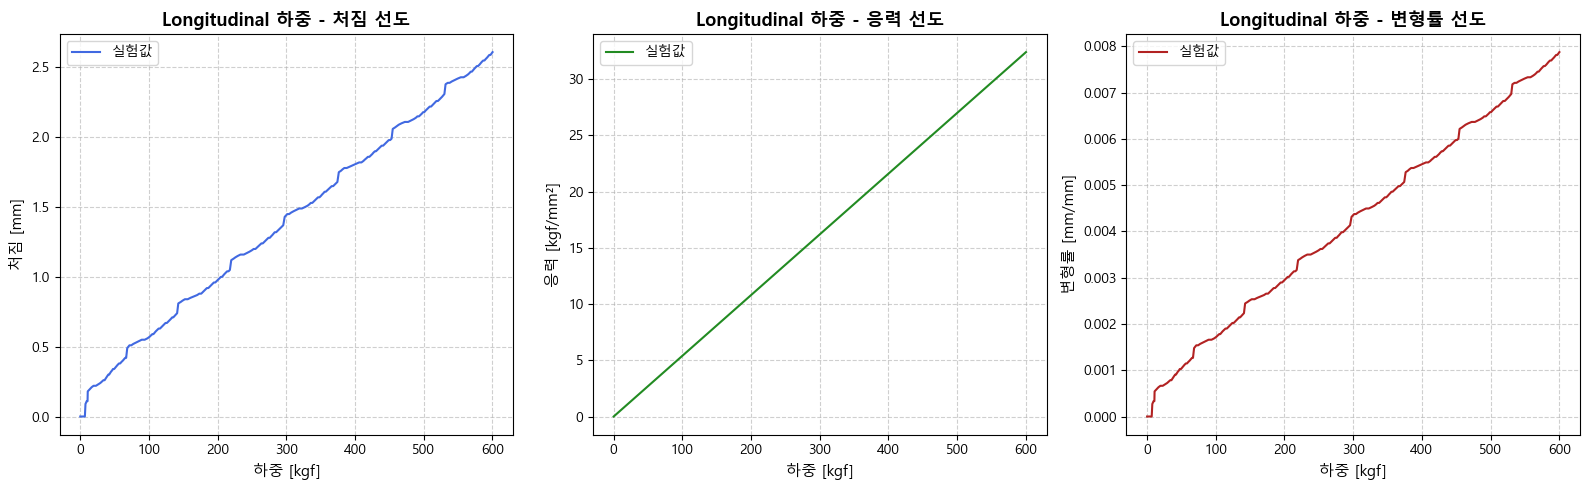

In [80]:
long_result.loc[1:, '하중'] = pd.to_numeric(long_result.loc[1:, '하중'])
long_result.loc[1:, '처짐'] = pd.to_numeric(long_result.loc[1:, '처짐'])
long_result.loc[1:, '응력'] = pd.to_numeric(long_result.loc[1:, '응력'])
long_result.loc[1:, '변형률'] = pd.to_numeric(long_result.loc[1:, '변형률'])

## 선형탄성 구간만
first_600_idx = long_result.loc[1:][long_result.loc[1:, '하중'] >= 600].index[0]
plot_data = long_result.loc[1:first_600_idx].copy()
tens_elastic = pd.concat([long_result.iloc[[0]], plot_data])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 하중-처짐 선도
axes[0].plot(plot_data['하중'],plot_data['처짐'],color='royalblue',linewidth=1.5,label='실험값',)
axes[0].set_title('Longitudinal 하중 - 처짐 선도', fontsize=13, fontweight='bold')
axes[0].set_xlabel('하중 [kgf]', fontsize=11)
axes[0].set_ylabel('처짐 [mm]', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# 하중-응력 선도
axes[1].plot(plot_data['하중'],plot_data['응력'],color='forestgreen',linewidth=1.5,label='실험값',)
axes[1].set_title('Longitudinal 하중 - 응력 선도', fontsize=13, fontweight='bold')
axes[1].set_xlabel('하중 [kgf]', fontsize=11)
axes[1].set_ylabel('응력 [kgf/mm²]', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

# 하중-변형률 선도
axes[2].plot(plot_data['하중'],plot_data['변형률'],color='firebrick',linewidth=1.5,label='실험값',)
axes[2].set_title('Longitudinal 하중 - 변형률 선도', fontsize=13, fontweight='bold')
axes[2].set_xlabel('하중 [kgf]', fontsize=11)
axes[2].set_ylabel('변형률 [mm/mm]', fontsize=11)
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend()

plt.tight_layout()
plt.show()

In [81]:
## Beam Theory
L = 130.0  # 지간거리 [mm]
b = 50.0  # 시편 너비 [mm]
d = 8.5  # 시편 두께 [mm]

coeff_delta = (L**3) / (4 * b * (d**3))
coeff_sigma = (3 * L) / (2 * b * (d**2))
coeff_eps = (3 * L) / (2 * b * (d**2))

gpa_to_kgf_mm2 = 1000.0 / 9.80665
coeff_delta_gpa = coeff_delta / gpa_to_kgf_mm2
coeff_eps_gpa = coeff_eps / gpa_to_kgf_mm2

print("=" * 65)
print(f"변위 [mm]      | ({coeff_delta_gpa:.6f} / E_f[GPa]) * P")
print(f"강도 [kgf/mm²] | {coeff_sigma:.6f} * P")
print(f"변형률 [mm/mm] | ({coeff_eps_gpa:.7f} / E_f[GPa]) * P")
print("=" * 65)

변위 [mm]      | (0.175414 / E_f[GPa]) * P
강도 [kgf/mm²] | 0.053979 * P
변형률 [mm/mm] | (0.0005294 / E_f[GPa]) * P


             선형탄성 구간 R-squared (R²) 계산 결과
하중-처짐 선도   | R² = 0.9374
하중-응력 선도   | R² = 1.0000
하중-변형률 선도 | R² = 0.9375


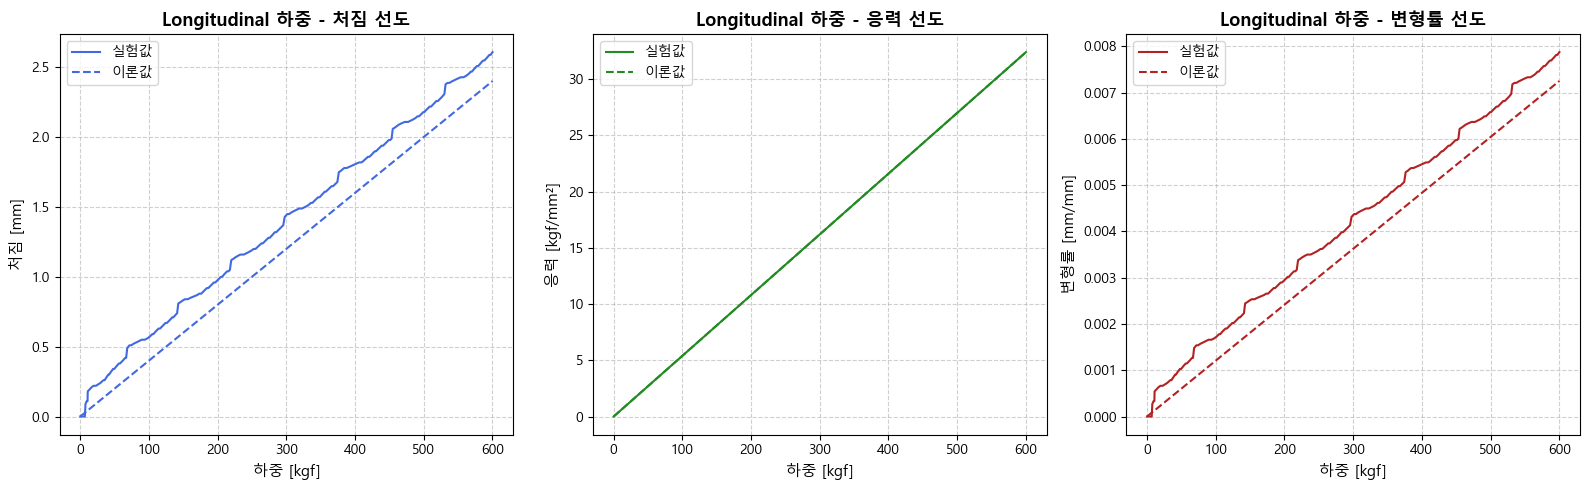

In [82]:
plot_data[['하중', '처짐', '응력', '변형률']] = plot_data[['하중', '처짐', '응력', '변형률']].astype(float)

E_f = 43.81 # GPa

coeff_delta_gpa = 0.1754 
coeff_sigma = 0.05398  
coeff_eps_gpa = 0.0005294  

P = plot_data['하중']
theory_deflection = (coeff_delta_gpa / E_f) * P
theory_stress = coeff_sigma * P
theory_strain = (coeff_eps_gpa / E_f) * P

# 결정계수 계산 함수 
def calc_r2_theory(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

# 각 선도별 R² 산출
r2_def_fit = calc_r2_theory(plot_data['처짐'], theory_deflection)
r2_stress_fit = calc_r2_theory(plot_data['응력'], theory_stress)
r2_strain_fit = calc_r2_theory(plot_data['변형률'], theory_strain)

# R² 콘솔 출력
print("=" * 60)
print("             선형탄성 구간 R-squared (R²) 계산 결과")
print("=" * 60)
print(f"하중-처짐 선도   | R² = {r2_def_fit:.4f}")
print(f"하중-응력 선도   | R² = {r2_stress_fit:.4f}")
print(f"하중-변형률 선도 | R² = {r2_strain_fit:.4f}")
print("=" * 60)

## 그래프
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 하중-처짐 선도
axes[0].plot(plot_data['하중'], plot_data['처짐'], color='royalblue', linewidth=1.5, label='실험값')
axes[0].plot(plot_data['하중'], theory_deflection, color='royalblue', linestyle='--', linewidth=1.5, label='이론값')
axes[0].set_title('Longitudinal 하중 - 처짐 선도', fontsize=13, fontweight='bold')
axes[0].set_xlabel('하중 [kgf]', fontsize=11)
axes[0].set_ylabel('처짐 [mm]', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()

# 하중-응력 선도
axes[1].plot(plot_data['하중'], plot_data['응력'], color='forestgreen', linewidth=1.5, label='실험값')
axes[1].plot(plot_data['하중'], theory_stress, color='forestgreen', linestyle='--', linewidth=1.5, label='이론값')
axes[1].set_title('Longitudinal 하중 - 응력 선도', fontsize=13, fontweight='bold')
axes[1].set_xlabel('하중 [kgf]', fontsize=11)
axes[1].set_ylabel('응력 [kgf/mm²]', fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

# 하중-변형률 선도
axes[2].plot(plot_data['하중'], plot_data['변형률'], color='firebrick', linewidth=1.5, label='실험값')
axes[2].plot(plot_data['하중'], theory_strain, color='firebrick', linestyle='--', linewidth=1.5, label='이론값')
axes[2].set_title('Longitudinal 하중 - 변형률 선도', fontsize=13, fontweight='bold')
axes[2].set_xlabel('하중 [kgf]', fontsize=11)
axes[2].set_ylabel('변형률 [mm/mm]', fontsize=11)
axes[2].grid(True, linestyle='--', alpha=0.6)
axes[2].legend()

plt.tight_layout()
plt.show()